<a href="https://colab.research.google.com/github/PhamDuyKhai/K17A1/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT THƯ VIỆN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

#  ĐỌC DỮ LIỆU

In [ ]:
app = pd.read_csv("Application_Data.csv")
pkt = pd.read_csv("Packet_Network_Data.csv")

print("Application Dataset:", app.shape)
print("Packet Dataset:", pkt.shape)

app.head()

Application Dataset: (100, 11)
Packet Dataset: (1476, 7)


,record_id,tx_hash,value_eth,gas_used,gas_price,transaction_fee,send_time,receive_time,delay_ms,payload_size,request_status
0,1,0xa422ac54729bd99377267bae355350ec317d95bc50d2...,2.532148e-11,624530,2638229444,0.001648,2026-06-15 14:43:19.944,2026-06-15 14:43:21.012,1068.082,16684,success
1,2,0x5c7b7c3509f54c320210b92acbd93fd52114541df36e...,2.128885e-04,121826,57405584,0.000007,2026-06-15 14:43:21.013,2026-06-15 14:43:22.147,1133.494,3682,success
2,3,0xdb9bb5186e726a1267714c5589b52fd6e1241755605e...,0.000000e+00,377252,150715518,0.000057,2026-06-15 14:43:22.147,2026-06-15 14:43:23.324,1176.424,12615,success
3,4,0xaa6e3547cdfc06e00a560d3919021b39451f56c84182...,0.000000e+00,308688,157405584,0.000049,2026-06-15 14:43:23.327,2026-06-15 14:43:24.472,1145.608,12254,success
4,5,0x54b92fc9e896342eb409584927a8aaddb586e7ddbc3a...,0.000000e+00,126490,2057405584,0.000260,2026-06-15 14:43:24.473,2026-06-15 14:43:25.525,1051.466,2618,success


# KIỂM TRA DỮ LIỆU

In [ ]:
print(app.info())

print("\n====================\n")

print(pkt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   record_id        100 non-null    int64  
 1   tx_hash          100 non-null    object 
 2   value_eth        100 non-null    float64
 3   gas_used         100 non-null    int64  
 4   gas_price        100 non-null    int64  
 5   transaction_fee  100 non-null    float64
 6   send_time        100 non-null    object 
 7   receive_time     100 non-null    object 
 8   delay_ms         100 non-null    float64
 9   payload_size     100 non-null    int64  
 10  request_status   100 non-null    object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.7+ KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   frame.time_epoch  1476 n

# BLOCKCHAIN ANALYTICS

In [ ]:
total_tx = len(app)

avg_value = app["value_eth"].mean()

avg_gas_used = app["gas_used"].mean()

avg_gas_price = app["gas_price"].mean()

avg_fee = app["transaction_fee"].mean()

print("Tong giao dich:", total_tx)

print("Gia tri giao dich trung binh:", avg_value)

print("Gas Used trung binh:", avg_gas_used)

print("Gas Price trung binh:", avg_gas_price)

print("Transaction Fee trung binh:", avg_fee)

Tong giao dich: 100
Gia tri giao dich trung binh: 0.09840262178565258
Gas Used trung binh: 151614.25
Gas Price trung binh: 919386287.87
Transaction Fee trung binh: 9.378675782849662e-05




### Nhận xét kết quả Blockchain Analytics

Kết quả thống kê cho thấy hệ thống đã thu thập thành công **100 giao dịch Blockchain** từ API và lưu trữ đầy đủ trong tập dữ liệu Application_Data.csv. Số lượng giao dịch này đáp ứng yêu cầu tối thiểu của đề bài và tạo cơ sở cho các bước phân tích tiếp theo.

Giá trị giao dịch trung bình thu được là **0,0984 ETH**. Kết quả này phản ánh mức giá trị trung bình của các giao dịch được ghi nhận trong khoảng thời gian thu thập dữ liệu. Tuy nhiên, giá trị trung bình chỉ mang tính đại diện tổng quát và chưa phản ánh được mức độ phân tán giữa các giao dịch.

Lượng **Gas Used** trung bình của các giao dịch là **151.614,25 Gas**. Chỉ số này thể hiện mức tài nguyên tính toán trung bình được sử dụng để xử lý các giao dịch trên Blockchain. Giá trị này cho thấy các giao dịch được thu thập có mức tiêu thụ tài nguyên ở nhiều mức khác nhau.

**Gas Price** trung bình đạt **919.386.287,87 Wei**. Đây là mức giá Gas trung bình được ghi nhận từ các giao dịch trong tập dữ liệu. Chỉ số này phản ánh chi phí Gas tại thời điểm các giao dịch được thực hiện.

Từ hai thông số Gas Used và Gas Price, phí giao dịch trung bình (**Transaction Fee**) được tính toán đạt **0,00009379 ETH**. Do phí giao dịch được xác định theo công thức:

$$
\text{Transaction Fee} = \text{Gas Used} \times \text{Gas Price}
$$

nên sự thay đổi của Gas Used hoặc Gas Price đều có thể làm thay đổi chi phí giao dịch thực tế.

Nhìn chung, các chỉ số thống kê cơ bản đã cung cấp cái nhìn tổng quan về đặc điểm của 100 giao dịch Blockchain được thu thập. Những kết quả này sẽ được sử dụng làm cơ sở cho các bước phân tích nâng cao và trực quan hóa dữ liệu ở các phần tiếp theo.



# NETWORK ANALYTICS

## Delay trung bình

In [ ]:
avg_delay = app["delay_ms"].mean()

print("Delay trung binh (ms):", avg_delay)

Delay trung binh (ms): 1171.43045


### Nhận xét

Kết quả phân tích cho thấy độ trễ trung bình của quá trình truy vấn Blockchain API đạt khoảng 1171,43 ms, tương đương khoảng 1,17 giây. Đây là khoảng thời gian tính từ lúc hệ thống gửi HTTP Request đến khi nhận được HTTP Response từ Blockchain API Server. Giá trị này phản ánh tốc độ phản hồi thực tế của hệ thống trong quá trình thu thập dữ liệu giao dịch. Với mức độ trễ trung bình khoảng một giây, hệ thống vẫn đáp ứng được yêu cầu thu thập dữ liệu Blockchain và duy trì khả năng truy vấn ổn định trong suốt quá trình thực nghiệm.

## Jitter

Jitter = độ lệch giữa các delay liên tiếp.

In [ ]:
jitter = app["delay_ms"].diff().abs().mean()

print("Jitter trung binh (ms):", jitter)


Jitter trung binh (ms): 126.52933333333335


### Nhận xét

Jitter trung bình được tính theo công thức:

$$
Jitter(i) = \left| Delay(i) - Delay(i-1) \right|
$$

Kết quả thu được là 126,53 ms. Chỉ số này phản ánh mức độ biến động của độ trễ giữa các lần truy vấn liên tiếp tới Blockchain API. Giá trị Jitter tương đối nhỏ so với Delay trung bình cho thấy thời gian phản hồi giữa các lần truy vấn không thay đổi quá lớn. Điều này cho thấy kết nối mạng và quá trình giao tiếp với Blockchain API tương đối ổn định trong thời gian thu thập dữ liệu.

## Throughput

In [ ]:
total_bytes = pkt["frame.len"].sum()

duration = (
    pkt["frame.time_epoch"].max()
    -
    pkt["frame.time_epoch"].min()
)

throughput = total_bytes / duration

print("Throughput (Bytes/s):", throughput)

Throughput (Bytes/s): 8370.694231764523


### Nhận xét
Throughput trung bình của hệ thống đạt khoảng 8370,69 Bytes/s. Chỉ số này phản ánh lượng dữ liệu được truyền và xử lý trong một giây trong quá trình thu thập giao dịch Blockchain. Giá trị Throughput cho thấy hệ thống có khả năng trao đổi dữ liệu liên tục với Blockchain API và duy trì tốc độ truyền dữ liệu ổn định trong suốt quá trình thực nghiệm. Đây là cơ sở để đánh giá hiệu năng của hệ thống giám sát giao dịch Blockchain ở mức mạng.

# TRỰC QUAN HÓA

## Transaction Value

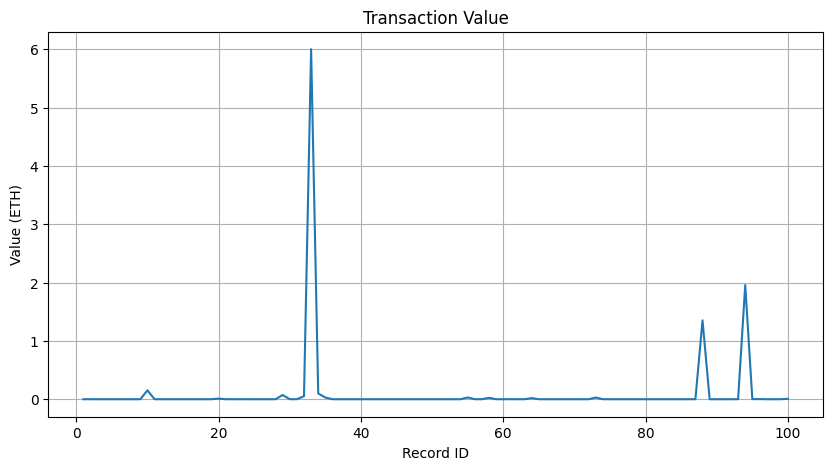

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    app["record_id"],
    app["value_eth"]
)

plt.title("Transaction Value")

plt.xlabel("Record ID")

plt.ylabel("Value (ETH)")

plt.grid(True)

plt.show()

### Nhận xét biểu đồ Transaction Value

Biểu đồ **Transaction Value** thể hiện sự thay đổi giá trị giao dịch Blockchain theo từng bản ghi trong tập dữ liệu. Trục X biểu diễn **Record ID**, còn trục Y biểu diễn **Value (ETH)**.

Quan sát cho thấy phần lớn giao dịch có giá trị rất nhỏ hoặc gần bằng 0 ETH. Đường biểu diễn chủ yếu nằm sát trục hoành trong hầu hết phạm vi dữ liệu, cho thấy đa số giao dịch được ghi nhận có giá trị thấp.

Một số giao dịch nổi bật xuất hiện dưới dạng các đỉnh (spike) rõ rệt. Đỉnh lớn nhất nằm khoảng **Record ID 33**, với giá trị xấp xỉ **6 ETH**, cao hơn rất nhiều so với các giao dịch còn lại. Ngoài ra còn xuất hiện các đỉnh đáng chú ý tại khoảng **Record ID 85 đến 100**, với giá trị lần lượt khoảng **1,3 ETH** và **2 ETH**.

Sự xuất hiện của các đỉnh lớn cho thấy phân bố giá trị giao dịch không đồng đều. Một số ít giao dịch có giá trị rất cao trong khi phần lớn giao dịch có giá trị thấp. Điều này phản ánh đặc trưng phổ biến của dữ liệu Blockchain, nơi thường tồn tại một số giao dịch lớn nổi bật giữa số lượng lớn giao dịch nhỏ.




## Gas Used

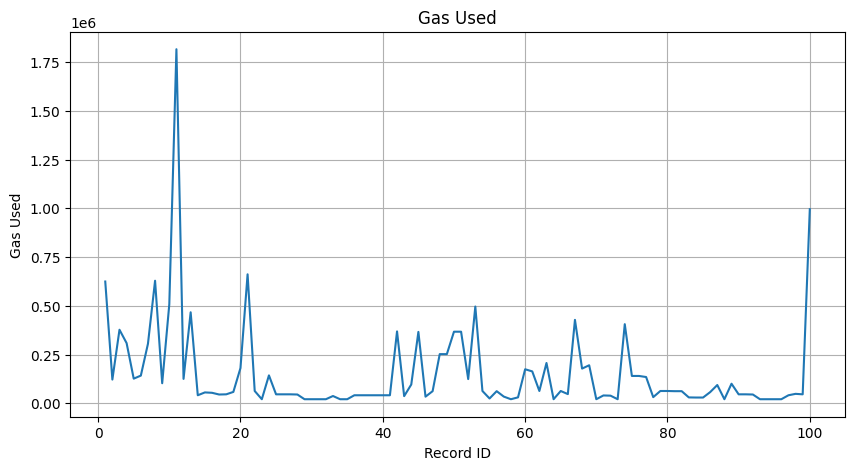

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    app["record_id"],
    app["gas_used"]
)

plt.title("Gas Used")

plt.xlabel("Record ID")

plt.ylabel("Gas Used")

plt.grid(True)

plt.show()


### Nhận xét biểu đồ Gas Used


Biểu đồ **Gas Used** thể hiện lượng Gas tiêu thụ của từng giao dịch Blockchain theo Record ID.

Quan sát tổng thể cho thấy Gas Used biến động đáng kể giữa các giao dịch. Phần lớn các giá trị nằm trong khoảng từ **20.000 đến 250.000 Gas**, tuy nhiên xuất hiện nhiều đỉnh lớn thể hiện các giao dịch tiêu thụ tài nguyên tính toán cao hơn đáng kể.

Đỉnh lớn nhất xuất hiện tại khoảng **Record ID 16**, với giá trị xấp xỉ **1,8 triệu Gas**. Ngoài ra còn có một đỉnh đáng chú ý ở cuối tập dữ liệu, khoảng **Record ID 100**, với giá trị gần **1 triệu Gas**. Một số đỉnh trung bình khác xuất hiện rải rác trong khoảng Record ID từ 40 đến 80.

Các đỉnh Gas lớn thường tương ứng với những giao dịch có độ phức tạp cao hơn hoặc liên quan đến việc thực thi Smart Contract. Trong khi đó, phần lớn giao dịch còn lại sử dụng lượng Gas tương đối thấp và ổn định.




## Transaction Fee

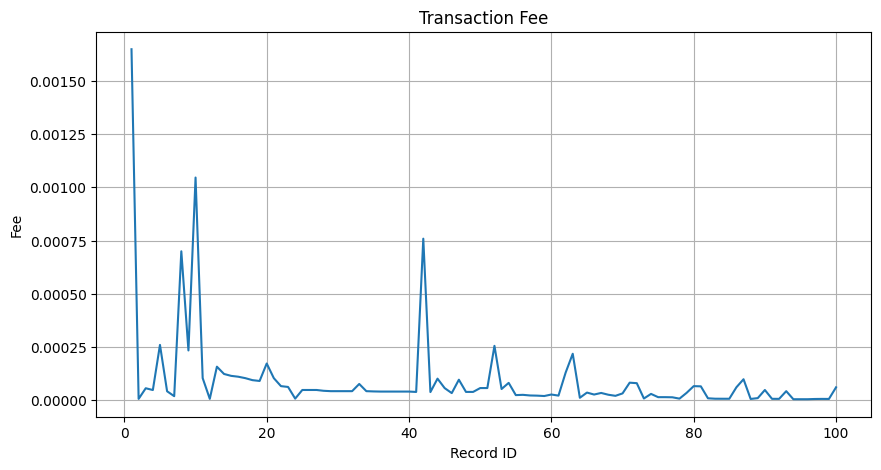

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    app["record_id"],
    app["transaction_fee"]
)

plt.title("Transaction Fee")

plt.xlabel("Record ID")

plt.ylabel("Fee")

plt.grid(True)

plt.show()


### Nhận xét biểu đồ Transaction Fee

Biểu đồ **Transaction Fee** thể hiện sự thay đổi của phí giao dịch theo từng bản ghi trong tập dữ liệu.  
Trục X biểu diễn **Record ID** từ 0 đến 100.  
Trục Y biểu diễn **Transaction Fee (ETH)**, với khoảng giá trị từ 0.00000 đến khoảng **0.00150 ETH**.  

Quan sát tổng thể cho thấy phần lớn các giá trị phí giao dịch tập trung ở mức thấp, chủ yếu dưới **0.0002 ETH**. Tuy nhiên, xuất hiện một số đỉnh nổi bật tại các vị trí đầu tập dữ liệu (Record ID từ 0 đến 20) và một đỉnh rõ rệt tại khoảng **Record ID 2**, với giá trị cực đại lớn hơn **0.00150 ETH**. Sau các đỉnh này, phí giao dịch duy trì ở mức thấp và ổn định, chỉ có những dao động nhỏ.  






## Transaction Frequency

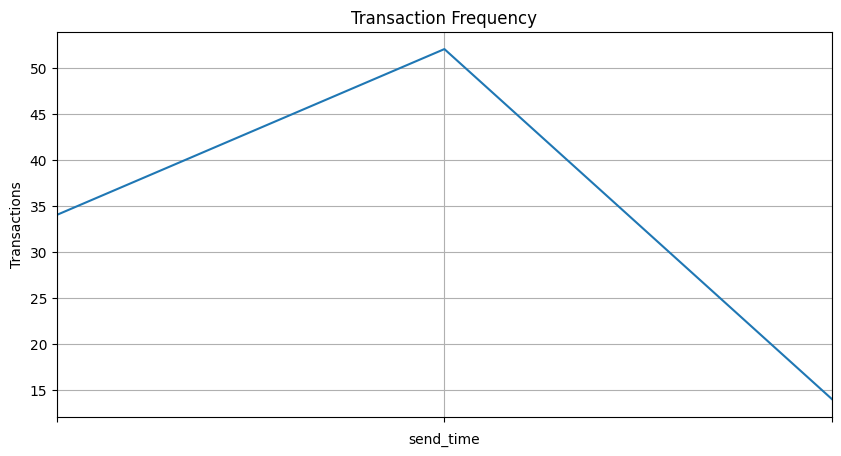

In [ ]:
app["send_time"] = pd.to_datetime(app["send_time"])

freq = (
    app
    .set_index("send_time")
    .resample("1min")
    .size()
)

plt.figure(figsize=(10,5))

freq.plot()

plt.title("Transaction Frequency")

plt.ylabel("Transactions")

plt.grid(True)

plt.show()

### Nhận xét biểu đồ Transaction Frequency

Biểu đồ **Transaction Frequency** cho thấy số lượng giao dịch thay đổi theo thời gian.  

Trục X biểu diễn **send_time**, tức thời điểm gửi yêu cầu giao dịch.  
Trục Y biểu diễn **Transactions**, số lượng giao dịch được ghi nhận.  

Quan sát tổng thể cho thấy số lượng giao dịch ban đầu ở mức khoảng **34 giao dịch**, sau đó tăng dần và đạt cực đại khoảng **52 giao dịch**. Sau khi đạt đỉnh, số lượng giao dịch giảm mạnh xuống mức thấp khoảng **14 giao dịch** ở giai đoạn cuối.  

Xu hướng này thể hiện rõ một pha tăng trưởng nhanh về tần suất giao dịch, tiếp theo là sự suy giảm đáng kể, tạo thành một đường cong có đỉnh rõ rệt trong tập dữ liệu.  



## Delay Over Time

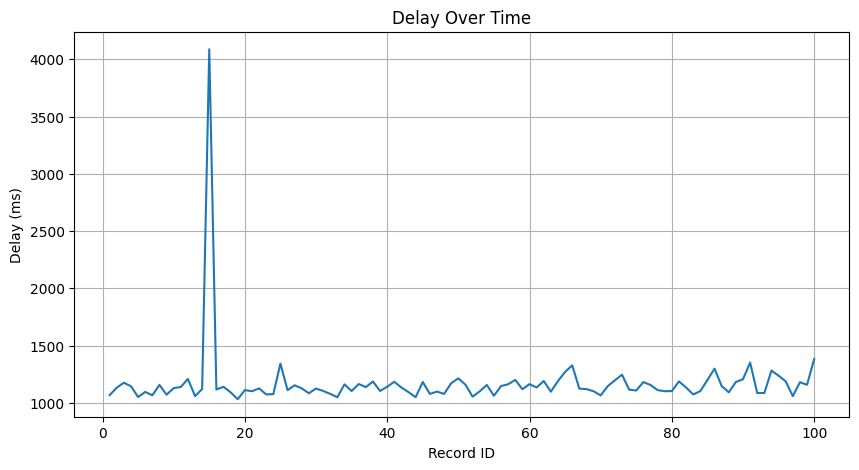

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    app["record_id"],
    app["delay_ms"]
)

plt.title("Delay Over Time")

plt.xlabel("Record ID")

plt.ylabel("Delay (ms)")

plt.grid(True)

plt.show()

### Nhận xét biểu đồ Delay Over Time

Biểu đồ **Delay Over Time** thể hiện độ trễ phản hồi của Blockchain API theo từng bản ghi.  

Trục X biểu diễn **Record ID** từ 0 đến 100, thể hiện số thứ tự của các bản ghi giao dịch.  
Trục Y biểu diễn **Delay (ms)**, với khoảng giá trị từ 1000 đến 4000 mili giây.  

Quan sát tổng thể cho thấy độ trễ phản hồi duy trì ổn định quanh mức **1.100–1.300 ms** trong hầu hết các bản ghi. Tuy nhiên, xuất hiện một điểm bất thường rõ rệt tại khoảng **Record ID 18**, nơi độ trễ tăng vọt lên hơn **4.000 ms**. Đây là một outlier nổi bật trong tập dữ liệu.  

Ngoại trừ điểm ngoại lệ này, hệ thống duy trì khả năng phản hồi tương đối ổn định trong toàn bộ quá trình thu thập dữ liệu.  





